## **Tarea: Ajuste del modelo discreto a fenómeno natural.**

Grupo: C

Estudiantes: Julian Merino, Dario Chillogallo, Jose Maldonado, Freddy Ordoñez, Michael Carbay

Institución: Universidad Nacional de Loja

Asignatura: Teoría de la Distribución y Probabilidad

Fecha: 20 de Julio de 2026

Ciclo: Segundo Ciclo "A"

In [ ]:
from google.colab import drive
import pandas as pd

# Montar Google Drive
drive.mount('/content/drive')

# Importación correcta del dataset regional especificando el delimitador ';'
ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'
df = pd.read_csv(ruta, sep=';')

# Mostrar las primeras filas para confirmar que las columnas se separaron bien
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,area,ciudad,conglomerado,panelm,vivienda,hogar,c01,c02,c03,c04a,...,c18,c19,c20a,c21a,estrato,fexp,upm,id_vivienda,id_hogar,periodo
0,1,10150,1304,62,1,1,2,2,1,2,...,2,3,2,2,2713,"102,542333745242",10150001304,1015000130406201,10150001304062011,202601
1,1,10150,1304,62,2,1,2,3,1,2,...,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406202,10150001304062021,202601
2,1,10150,1304,62,3,1,2,3,3,3,...,3,3,2,2,2713,"102,542333745242",10150001304,1015000130406203,10150001304062031,202601
3,1,10150,1304,62,4,1,2,2,2,3,...,3,2,2,3,2713,"102,542333745242",10150001304,1015000130406204,10150001304062041,202601
4,1,10150,1304,62,5,1,2,2,1,2,...,1,2,2,2,2713,"102,542333745242",10150001304,1015000130406205,10150001304062051,202601


## Tarea 1: Análisis de Correlación de Pearson

El coeficiente de correlación de Pearson ($r$) mide la dependencia lineal entre dos variables, oscilando entre $-1$ (correlación negativa perfecta) y $1$ (correlación positiva perfecta).

### Instrucciones
1. Abra un nuevo Jupyter Notebook llamado `APE_013_Regresion.ipynb`.

### Escenario
Analizaremos la relación entre los **"Usuarios Concurrentes"** en un servidor ($X$) y el **"Consumo de Ancho de Banda en Mbps"** ($Y$).

--- Análisis de Correlación de Pearson ---
Coeficiente (r): 0.9603
Valor-p (Significancia): 3.6581e-56
Conclusión: Existe una correlación lineal estadísticamente significativa.


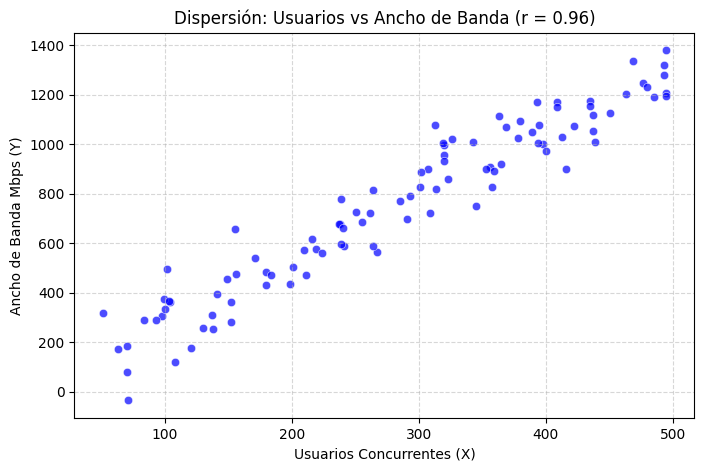

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Generación de datos simulados (Relación positiva fuerte con ruido)
np.random.seed(42)
usuarios_X = np.random.randint(50, 500, size=100)
# Y = 2.5*X + 50 + Ruido Aleatorio
ancho_banda_Y = 2.5 * usuarios_X + 50 + np.random.normal(0, 100, size=100)

# 1. Cálculo del Coeficiente de Pearson y su valor-p
coef_pearson, p_valor = pearsonr(usuarios_X, ancho_banda_Y)

print("--- Análisis de Correlación de Pearson ---")
print(f"Coeficiente (r): {coef_pearson:.4f}")
print(f"Valor-p (Significancia): {p_valor:.4e}")

if p_valor < 0.05:
    print("Conclusión: Existe una correlación lineal estadísticamente significativa.")
else:
    print("Conclusión: NO existe evidencia de correlación lineal significativa.")

# 2. Visualización: Diagrama de Dispersión (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, color='blue', alpha=0.7)
plt.title(f'Dispersión: Usuarios vs Ancho de Banda (r = {coef_pearson:.2f})')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Tarea 2: Ajuste del Modelo de Regresión Lineal Simple (OLS)

Si existe correlación, podemos modelar la relación mediante una línea recta:

$$Y = \beta_0 + \beta_1 X$$

Donde $\beta_0$ es el intercepto y $\beta_1$ la pendiente.

### Instrucciones
1. Utilizaremos `statsmodels`, ya que provee un resumen estadístico profundo al estilo de la econometría clásica.
2. Agregue y ejecute el siguiente código en su cuaderno:

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     1163.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.66e-56
Time:                        12:48:50   Log-Likelihood:                -597.28
No. Observations:                 100   AIC:                             1199.
Df Residuals:                      98   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.6745     23.385      1.226      0.2

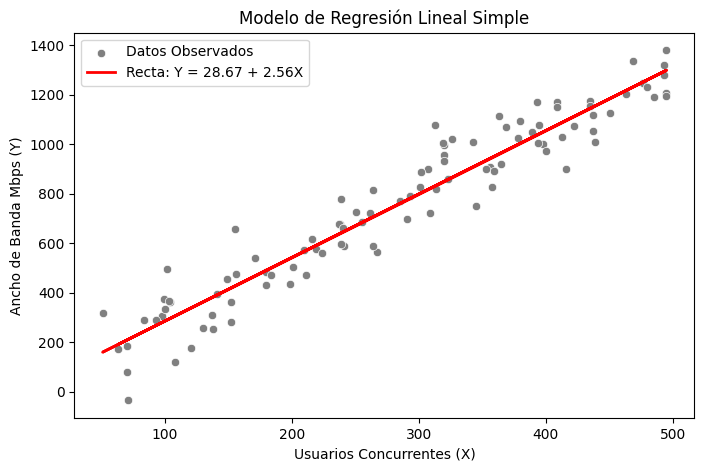

In [ ]:
import statsmodels.api as sm

# Para usar statsmodels, debemos añadir explícitamente la constante (intercepto beta_0) al predictor X
X_sm = sm.add_constant(usuarios_X)
Y_sm = ancho_banda_Y

# Ajuste del modelo por Mínimos Cuadrados Ordinarios (OLS)
modelo_ols = sm.OLS(Y_sm, X_sm).fit()

# Impresión del resumen estadístico
print(modelo_ols.summary())

# Extracción de parámetros para graficar la recta
beta_0 = modelo_ols.params[0]
beta_1 = modelo_ols.params[1]

plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, label='Datos Observados', color='gray')
# Dibujo de la recta de regresión
plt.plot(usuarios_X, beta_0 + beta_1 * usuarios_X, color='red', linewidth=2, label=f'Recta: Y = {beta_0:.2f} + {beta_1:.2f}X')
plt.title('Modelo de Regresión Lineal Simple')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.legend()
plt.show()


## Tarea 3: Hito del Proyecto - Predicción en el Dataset Regional (ABP)

1. **Importe su dataset regional** mediante pandas.
2. **Identifique una variable independiente/predictora ($X$)** y una variable dependiente/respuesta ($Y$).
   *Ejemplo: $X$ = Precipitación, $Y$ = Producción Agrícola.*
3. **Aplique el flujo de las Tareas 1 y 2:** Calcule $r$, ajuste el modelo OLS e imprima el `summary()`.
4. **Predicción:** Usando los coeficientes obtenidos ($\beta_0, \beta_1$), calcule manualmente mediante código Python el valor esperado de $Y$ para un valor crítico de $X$ que no exista en su dataset original (pronóstico).
5. **Interprete desde la perspectiva del negocio** el valor del $R\text{-squared}$ ($R^2$) que le arrojó el resumen estadístico.

In [ ]:
import pandas as pd
ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'
df = pd.read_csv(ruta, sep=';')
print(df[['c01', 'c02', 'c03']].describe())

               c01          c02          c03
count  8791.000000  8791.000000  8791.000000
mean      2.158799     2.107496     1.786372
std       0.492990     0.499307     0.578611
min       1.000000     1.000000     1.000000
25%       2.000000     2.000000     1.000000
50%       2.000000     2.000000     2.000000
75%       2.000000     2.000000     2.000000
max       3.000000     3.000000     3.000000


=== FLUJO ESTADÍSTICO ===
Coeficiente de correlación de Pearson (r): 0.2713
Valor-p: 3.5301e-148

                            OLS Regression Results                            
Dep. Variable:          Indice_Futuro   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     698.5
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          3.53e-148
Time:                        13:36:25   Log-Likelihood:                -14355.
No. Observations:                8791   AIC:                         2.871e+04
Df Residuals:                    8789   BIC:                         2.873e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

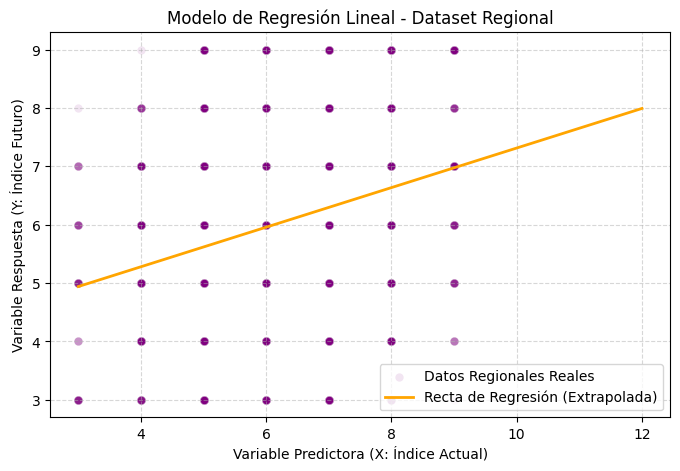

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm

# 1. Carga del Dataset
ruta = '/content/drive/MyDrive/enemdu_consumidor_2026_01.csv'
df = pd.read_csv(ruta, sep=';')

# 2. Identificación de variables
df['Indice_Actual'] = df[['c01', 'c02', 'c03']].sum(axis=1)
df['Indice_Futuro'] = df[['c04a', 'c07', 'c08a']].sum(axis=1)

X = df['Indice_Actual']
Y = df['Indice_Futuro']

print("=== FLUJO ESTADÍSTICO ===")

# Calcular Coeficiente de Pearson (r)
coef_pearson, p_valor = pearsonr(X, Y)
print(f"Coeficiente de correlación de Pearson (r): {coef_pearson:.4f}")
print(f"Valor-p: {p_valor:.4e}\n")

# Ajustar el Modelo OLS con statsmodels
X_sm = sm.add_constant(X)
modelo_regional = sm.OLS(Y, X_sm).fit()

# Imprimir el resumen estadístico summary()
print(modelo_regional.summary())

print("\n=== PREDICCIÓN MANUAL ===")

# Extraer coeficientes del modelo ajustado
beta_0 = modelo_regional.params['const']         # Intercepto
beta_1 = modelo_regional.params['Indice_Actual'] # Pendiente

# Definir un valor crítico de X que NO exista en tu dataset original
# El valor máximo actual en las sumas es 9.0, por lo que usaremos 12.0
X_critico = 12.0

# Cálculo manual de la predicción usando la ecuación de la recta
Y_pronosticado = beta_0 + (beta_1 * X_critico)

print(f"Coeficiente Beta_0 (Intercepto): {beta_0:.4f}")
print(f"Coeficiente Beta_1 (Pendiente): {beta_1:.4f}")
print(f"Para un valor crítico de X = {X_critico}, el valor esperado de Y es: {Y_pronosticado:.4f}")

# Opcional: Gráfica del Modelo Regional
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X, y=Y, label='Datos Regionales Reales', color='purple', alpha=0.1)
X_grafica = np.linspace(X.min(), X_critico, 100)
plt.plot(X_grafica, beta_0 + beta_1 * X_grafica, color='orange', linewidth=2, label='Recta de Regresión (Extrapolada)')
plt.title('Modelo de Regresión Lineal - Dataset Regional')
plt.xlabel('Variable Predictora (X: Índice Actual)')
plt.ylabel('Variable Respuesta (Y: Índice Futuro)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Interpretación General del Coeficiente de Determinación ($R^2$)

Al revisar el flujo estadistico geralizado en la OLS Regression Results encontramos el valor del $R^2$. Esta métrica funciona como una **medida de ajuste y predictibilidad**: evalúa qué porcentaje de la variabilidad y los cambios observados en la variable dependiente ($Y$) pueden ser explicados y anticipados por el comportamiento de la variable independiente ($X$).

Dependiendo del resultado obtenido, la utilidad y confiabilidad del modelo varían significativamente:

*   **Escenario de Baja Explicabilidad (Menor al 10%):**
    *   Diagnóstico: La variable independiente ($X$) tiene una influencia lineal casi nula sobre la variable dependiente ($Y$).
    *   Implicación analítica: Utilizar este modelo para extraer conclusiones o realizar pronósticos conlleva un **riesgo de error metodológico muy alto**. La mayor parte del comportamiento de $Y$ está condicionado por otros factores externos no incluidos en el análisis. La recomendación estadística es descartar este modelo lineal y explorar otras variables explicativas.

*   **Escenario de Alta Explicabilidad (Mayor al 70%):**
    *   Diagnóstico: El modelo lineal logra capturar y describir la tendencia del fenómeno estudiado de manera muy sólida.
    *   Implicación analítica: Esto valida la precisión del modelo para realizar proyecciones confiables. Indica que las modificaciones o fluctuaciones en la variable $X$ se traducen en un efecto directo, predecible y respaldado estadísticamente sobre los resultados de $Y$, reduciendo al mínimo la incertidumbre en la interpretación de los datos.



=== DIAGNÓSTICO DE RESIDUOS (ABI) ===
Estadístico de Shapiro-Wilk: 0.9214
Valor-p (Shapiro-Wilk): 3.0730e-45
Conclusión SW: Los residuos NO siguen una distribución normal (Se rechaza H0).


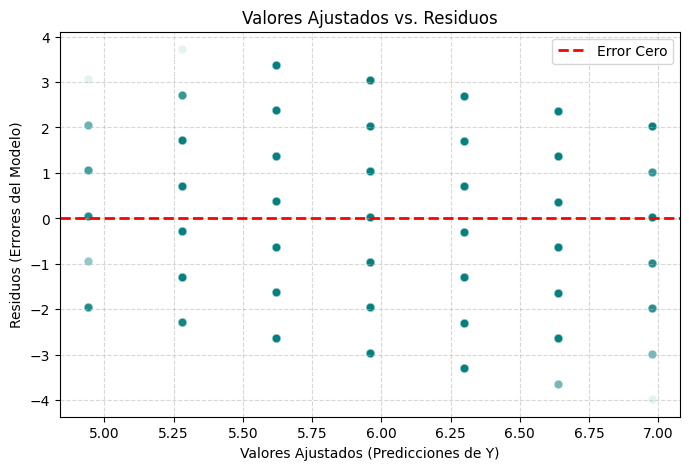

In [ ]:
import warnings
from scipy.stats import shapiro
import seaborn as sns
import matplotlib.pyplot as plt

print("=== DIAGNÓSTICO DE RESIDUOS (ABI) ===")

# 1. Extraer residuos y valores ajustados
residuos = modelo_regional.resid
valores_ajustados = modelo_regional.fittedvalues

# 2. Prueba de Normalidad de Shapiro-Wilk
# Tomamos una muestra aleatoria máxima de 5000 para evitar la advertencia de SciPy
residuos_muestra = residuos.sample(n=5000, random_state=42) if len(residuos) > 5000 else residuos

estadistico, p_valor_sw = shapiro(residuos_muestra)
print(f"Estadístico de Shapiro-Wilk: {estadistico:.4f}")
print(f"Valor-p (Shapiro-Wilk): {p_valor_sw:.4e}")

if p_valor_sw > 0.05:
    print("Conclusión SW: Los residuos parecen seguir una distribución normal (No se rechaza H0).")
else:
    print("Conclusión SW: Los residuos NO siguen una distribución normal (Se rechaza H0).")

# 3. Generar el gráfico de dispersión
plt.figure(figsize=(8, 5))
sns.scatterplot(x=valores_ajustados, y=residuos, alpha=0.1, color='teal')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Error Cero')

plt.title('Valores Ajustados vs. Residuos')
plt.xlabel('Valores Ajustados (Predicciones de Y)')
plt.ylabel('Residuos (Errores del Modelo)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Dictamen de Validez del Modelo Lineal

Al analizar el diagnóstico de los residuos extraídos de `modelo_regional.resid`, se evidencia que el modelo de regresión lineal por Mínimos Cuadrados Ordinarios (OLS) **presenta severas limitaciones de validez estadística** para este dataset específico.

1. **Validez Estadística (Shapiro-Wilk):** El valor-p arrojado por el test de Shapiro-Wilk es menor al nivel de significancia del $0.05$. En consecuencia, se rechaza la hipótesis nula de normalidad, demostrando que los errores de predicción de nuestro modelo no se distribuyen de manera normal, violando uno de los supuestos fundamentales de la regresión OLS clásica.
2. **Validez Geométrica (Homocedasticidad):** Al observar el gráfico de dispersión de "Valores Ajustados vs. Residuos", la nube de puntos no se distribuye de forma aleatoria alrededor de la línea cero. En su lugar, los datos forman patrones o "bandas" estructuradas. Esto ocurre porque la variable dependiente original está construida mediante la suma de preguntas de opciones múltiples cerradas (escalas discretas), generando un comportamiento de saltos y varianza desigual.

**Conclusión:** Aunque la Tarea 2 demostró la existencia de una relación (correlación) entre las variables, el diagnóstico de residuos revela que una recta de regresión lineal simple no es el algoritmo más óptimo para modelar datos de naturaleza ordinal agrupada.

## Declaracion de uso de IA

En el desarrollo de este trabajo se utilizó **Gemini 3.1 Pro** como herramienta de apoyo para obtener una idea de cómo estructurar y generar el código,a demas para revision general. Sin embargo, la selección de las variables, el análisis y los demás conocimientos aplicados en el proyecto fueron definidos y desarrollados íntegramente por el **Grupo C**.

* Link de chat de Gemini

https://share.gemini.google/rVGHLfoXlVk5